# Disk prior: cylindrical sampling vs analytical formula

Draw $10^7$ stars from the 3D exponential disk in Galactocentric cylindrical
coordinates, convert to heliocentric $(d, \ell, b)$, and compare the radial
distribution in narrow $(\ell, b)$ bins with the analytical prior
$$
p(d \mid \ell, b) \propto d^2 \exp\!\left(-\frac{R_{\rm GC}}{R_d}\right)
\exp\!\left(-\frac{|z|}{z_d}\right).
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

R_d = 2.5      # disk scale length [kpc]
z_d = 0.1      # disk scale height [kpc]
R_sun = 8.122  # solar Galactocentric distance [kpc]
N = 10_000_000

## Draw from 3D disk in cylindrical coordinates

- $R_{\rm GC} \sim \mathrm{Gamma}(2, R_d)$, i.e. $p(R) \propto R\,e^{-R/R_d}$
- $\phi_{\rm GC} \sim \mathrm{Uniform}(0, 2\pi)$
- $z \sim \mathrm{Laplace}(0, z_d)$, i.e. $p(z) \propto e^{-|z|/z_d}$

In [2]:
rng = np.random.default_rng(42)

R_GC = rng.gamma(2, R_d, size=N)
phi_GC = rng.uniform(0, 2 * np.pi, size=N)
z = rng.laplace(0, z_d, size=N)

# Galactocentric Cartesian (X toward Sun, Y direction of rotation)
X_GC = R_GC * np.cos(phi_GC)
Y_GC = R_GC * np.sin(phi_GC)

# Heliocentric Cartesian
x_h = R_sun - X_GC
y_h = Y_GC
z_h = z

d = np.sqrt(x_h**2 + y_h**2 + z_h**2)
b = np.degrees(np.arcsin(z_h / d))
ell = np.degrees(np.arctan2(y_h, x_h)) % 360

print(f"d: [{d.min():.3f}, {d.max():.1f}] kpc")
print(f"ell: [{ell.min():.1f}, {ell.max():.1f}] deg")
print(f"b: [{b.min():.1f}, {b.max():.1f}] deg")

d: [0.009, 59.3] kpc
ell: [0.0, 360.0] deg
b: [-87.9, 88.9] deg


## Analytical disk prior

In [3]:
def disk_prior_bin_averaged(d_grid, ell0, b0, half_width, n_quad=32):
    """Disk prior averaged over an (ell, b) bin.

    Computes int cos(b) * d^2 exp(-R_GC/R_d) exp(-|z|/z_d) dell db
    on a grid of distances using 2D Gauss-Legendre quadrature.
    """
    from numpy.polynomial.legendre import leggauss
    nodes, weights = leggauss(n_quad)

    # Map nodes to [ell0-hw, ell0+hw] and [b0-hw, b0+hw]
    hw = half_width
    ell_pts = np.radians(ell0 + hw * nodes)  # (n_quad,)
    b_pts = np.radians(b0 + hw * nodes)      # (n_quad,)
    w_ell = weights                            # (n_quad,)
    w_b = weights                              # (n_quad,)

    # d_grid: (n_d,), ell_pts: (n_ell,), b_pts: (n_b,)
    # Broadcast to (n_d, n_ell, n_b)
    dg = d_grid[:, None, None]
    el = ell_pts[None, :, None]
    bp = b_pts[None, None, :]

    x = dg * np.cos(bp) * np.cos(el)
    y = dg * np.cos(bp) * np.sin(el)
    z = dg * np.sin(bp)
    R_GC = np.sqrt((R_sun - x)**2 + y**2)

    log_integrand = (2 * np.log(dg) - R_GC / R_d - np.abs(z) / z_d
                     + np.log(np.cos(bp)))

    # Stabilise before exp
    log_max = log_integrand.max(axis=(1, 2), keepdims=True)
    integrand = np.exp(log_integrand - log_max)

    # 2D quadrature: sum over ell and b with weights
    p = np.einsum('dij,i,j->d', integrand, w_ell, w_b)
    log_p = np.log(p) + log_max.squeeze()

    return log_p

## Compare in narrow $(\ell, b)$ bins

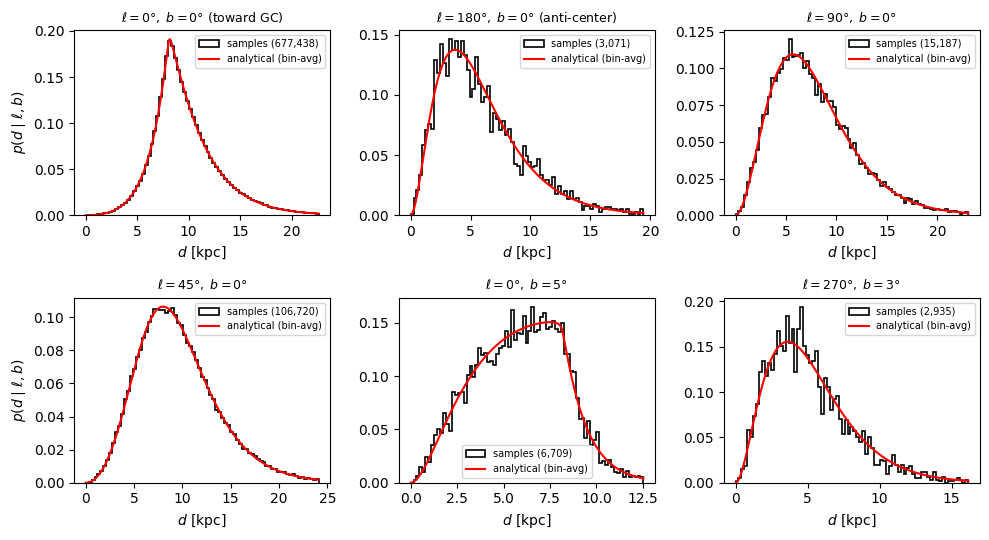

In [4]:
sightlines = [
    (0, 0, r"$\ell=0°,\; b=0°$ (toward GC)"),
    (180, 0, r"$\ell=180°,\; b=0°$ (anti-center)"),
    (90, 0, r"$\ell=90°,\; b=0°$"),
    (45, 0, r"$\ell=45°,\; b=0°$"),
    (0, 5, r"$\ell=0°,\; b=5°$"),
    (270, 3, r"$\ell=270°,\; b=3°$"),
]

half_width = 2  # ±2 deg bin

fig, axes = plt.subplots(2, 3, figsize=(10, 5.5))
axes = axes.ravel()

for ax, (ell0, b0, title) in zip(axes, sightlines):
    # Select stars in the bin
    dell = (ell - ell0 + 180) % 360 - 180
    mask = (np.abs(dell) < half_width) & (np.abs(b - b0) < half_width)
    d_bin = d[mask]

    d_max = np.percentile(d_bin, 99.5) if len(d_bin) > 100 else 20
    bins = np.linspace(0, d_max, 80)

    ax.hist(d_bin, bins=bins, density=True, histtype='step',
            lw=1.2, color='k', label=f'samples ({len(d_bin):,})')

    # Analytical curve averaged over the bin
    d_grid = np.linspace(1e-3, d_max, 500)
    log_p = disk_prior_bin_averaged(d_grid, ell0, b0, half_width)
    p = np.exp(log_p - log_p.max())
    p /= np.trapezoid(p, d_grid)
    ax.plot(d_grid, p, 'r-', lw=1.5, label='analytical (bin-avg)')

    ax.set_title(title, fontsize=9)
    ax.set_xlabel('$d$ [kpc]')
    ax.legend(fontsize=7, frameon=True)

axes[0].set_ylabel(r'$p(d \mid \ell, b)$')
axes[3].set_ylabel(r'$p(d \mid \ell, b)$')
fig.tight_layout()
plt.show()